## 모멘텀 기반 ETF 로테이션 전략

이 전략은 강한 모멘텀을 보이는 ETF에 집중 투자하는 방식  
상승장이 지속될 때 높은 수익을 기대  
반면, 변동성이 크거나 하락장이 오면 손실 위험  


✅ 모멘텀 기반 ETF 로테이션 전략  
✅ 매월 초 최근 20일(한 달) 동안 가장 성과가 좋았던 ETF 10개를 매수  
✅ 나머지 ETF는 모두 매도하여 정리  
✅ 각 ETF는 동일 비중(10%)으로 보유  



### 1. 초기 설정 (initialize 함수)
- 투자 대상: sector_etfs 리스트에 있는 ETF들
- 과거 데이터 기간: 최근 20일 (context.history_window = 20)
- 보유할 종목 수: 10개 (context.stocks_to_hold = 10)
- 거래 시점: 매월 첫 거래일에 시장 마감 직전(date_rules.month_start(), time_rules.market_close())


### 2. 모멘텀 계산 (month_perf 함수)
- 주어진 ETF의 최근 20일(약 1개월) 수익률을 계산하여 반환

### 3. 매월 리밸런싱 (handle_data 함수)
- 모든 ETF의 최근 20일 수익률을 계산
- 수익률 기준 내림차순 정렬 후 상위 10개 ETF를 선정 (buy_list)
- 선정된 ETF를 동일 비중(10%)으로 매수
- 나머지 ETF는 전량 매도

### 4. 성과 분석 (analyze 함수)
- pyfolio 라이브러리를 활용하여 성과 분석을 수행
- 수익률(returns), 포지션(positions), 거래 내역(transactions)을 추출
- pf.create_returns_tear_sheet()을 사용하여 수익률 분석 리포트를 생성

In [1]:
from zipline import run_algorithm
from zipline.api import symbol, order_target_percent, schedule_function, date_rules, time_rules
from datetime import datetime
import pyfolio as pf
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [17]:
sector_etfs = [
    'SPY',  # Financials
    'GLD',  # Technology
    'XLE',  # Energy
    'TLT',  # Consumer Discretionary
    'XLK',  # Consumer Staples
    'XLU',  # Health Care
    'XLP',  # Industrials
    'COPX',  # Materials
    'XLB',  # Utilities
    'EWZ',   # Real Estate
    'XLV',  # Industrials
    'XLI',  # Materials
    'XLY',  # Utilities
    'XLF',  # Utilities
    'XLC',  # Utilities
    'OIH',  # Utilities
    'EWJ',  # Utilities
]

In [18]:
def initialize(context)-> None:
    context.universe = [symbol(s) for s in  sector_etfs]
    context.history_window = 20
    context.stocks_to_hold = 10
    schedule_function(func = handle_data,
                      date_rule = date_rules.month_start(), time_rule=time_rules.market_close(), half_days=True, calendar=None)

def month_perf(ts:"time series"):  # 수익률로 변환
    perf = (ts[-1] / ts[0] -1)
    return perf


def handle_data(context, data):
    hist = data.history(assets= context.universe, fields="close",bar_count = context.history_window, frequency = '1d')
    perf_table = hist.apply(month_perf).sort_values(ascending=False)
    buy_list = perf_table[: context.stocks_to_hold]
    the_rest = perf_table[context.stocks_to_hold:] 
    for stock, perf in buy_list.items():
        stock_weight = 1 / context.stocks_to_hold
        if data.can_trade(stock):
            order_target_percent(stock, stock_weight)
    for stock, perf in the_rest.items():
        if data.can_trade(stock):
            order_target_percent(stock, 0.0)     


def analyze(context, perf):
    returns, postions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) #수익률, 포지션, 거래 반환
    pf.create_returns_tear_sheet(returns, benchmark_rets=None)

In [21]:
start_date = pd.Timestamp('2010-01-01').tz_localize(None)
end_date = pd.Timestamp('2024-07-01').tz_localize(None)

Start date,2010-01-04
End date,2024-07-01
Total months,173
,Backtest
Annual return,8.197%
Cumulative returns,212.722%
Annual volatility,14.966%
Sharpe ratio,0.60
Calmar ratio,0.32
Stability,0.93
Max drawdown,-25.868%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,25.87,2018-01-26,2020-03-23,2020-06-03,614
1,22.69,2022-04-04,2022-09-30,2024-03-20,513
2,19.75,2015-05-04,2016-02-11,2017-01-25,453
3,16.61,2011-05-10,2011-10-03,2012-02-24,209
4,12.94,2010-04-23,2010-07-01,2010-10-12,123


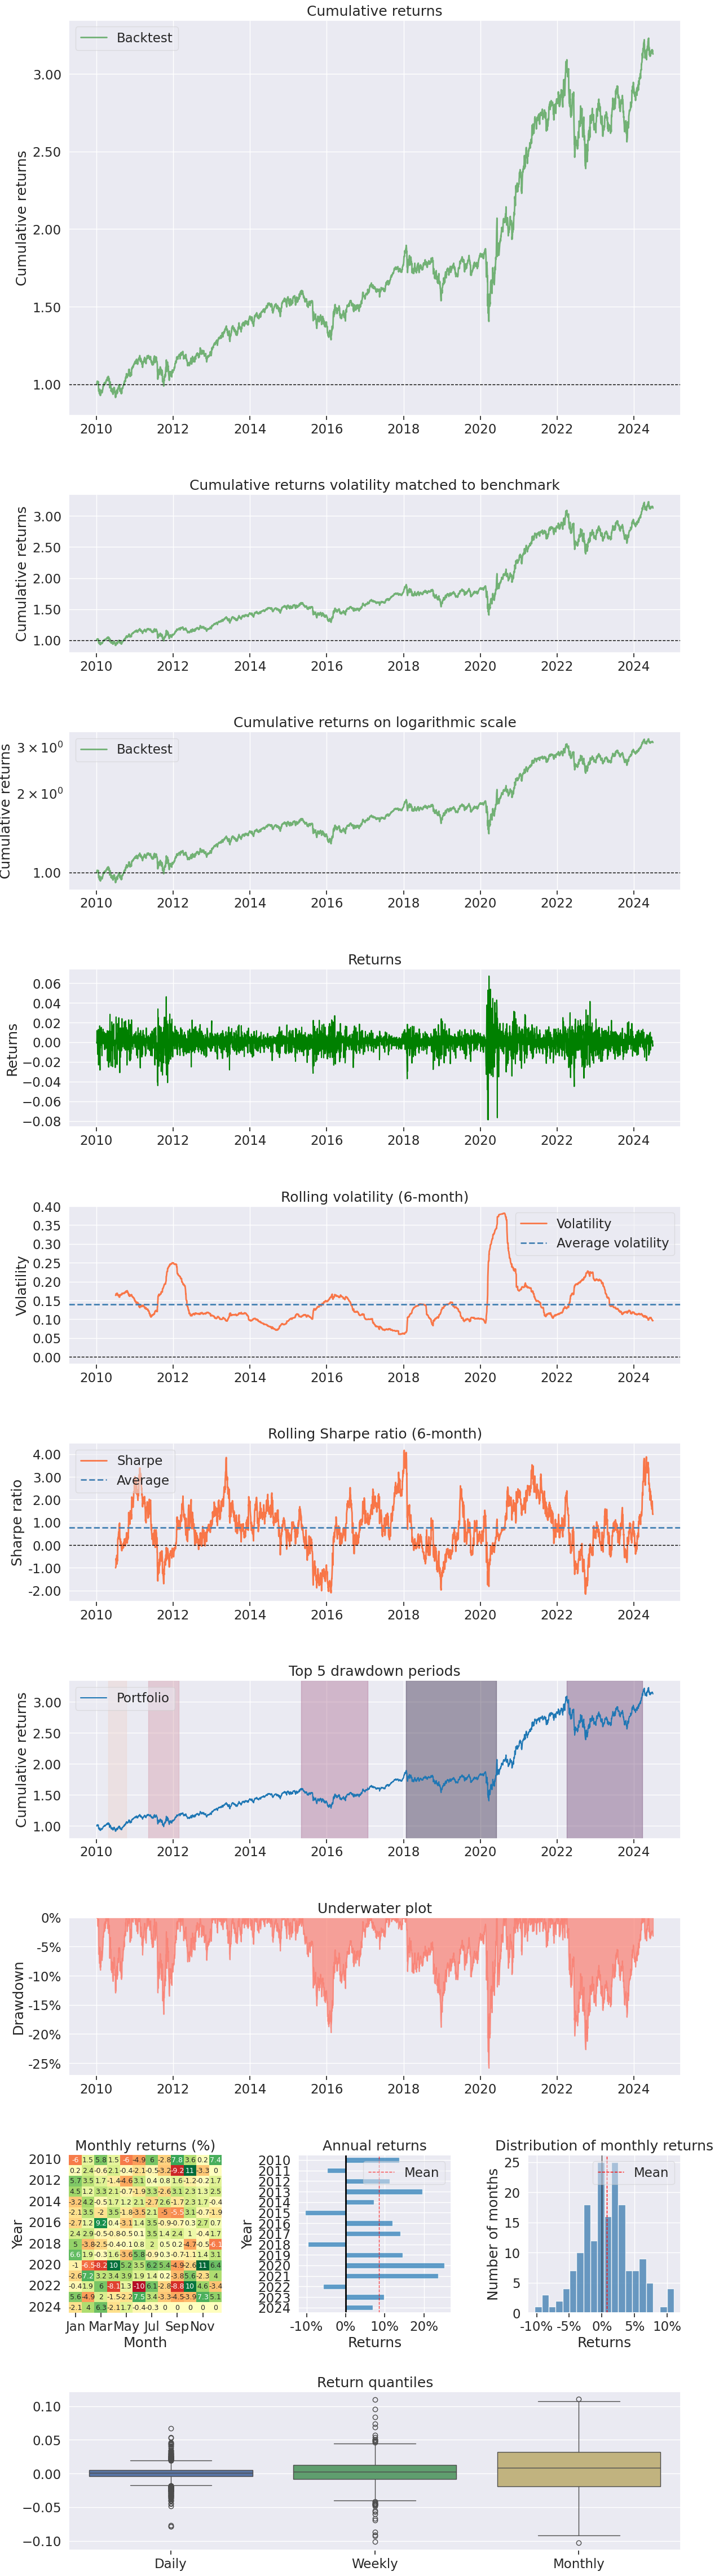

In [22]:
results = run_algorithm(
    start=start_date,
    end=end_date,
    initialize=initialize,
    handle_data=handle_data,
    analyze=analyze,
    capital_base=10000,
    data_frequency='daily',
    bundle='us_etfs'
)